# ВШЭ, 2026: Математические методы анализа данных

## Семинар 4: Метрики классификации

**Авторы**: Полина Полунина, Андрей Шестаков


## Сегодня:
* Классификация ирисов на 2 класса с помощью логистической регрессии
* Метрики классификации
* Работа с несбалансированными данными

#### Импортируем библиотеки:

In [1]:
#линейная алгебра
import numpy as np
#структуры данных
import pandas as pd
#ML-модели
import scipy as sp
import sklearn
from sklearn import datasets
from sklearn import metrics
from sklearn.metrics import accuracy_score
#логистическая регрессия
from sklearn.linear_model import LogisticRegression
#графики
import matplotlib.pyplot as plt
%matplotlib inline
#красивые графики
import seaborn as sns
#задаём стиль графиков
sns.set_style('darkgrid')
#отключаем предупреждения
import warnings
warnings.filterwarnings("ignore")

#### Загружаем датасет:

In [2]:
X, Y = sklearn.datasets.load_iris(return_X_y=True)
names = ['sepal length', 'sepal width', 'petal length', 'petal width']
classes = ['setosa', 'versicolor', 'virginica']

#собираем таблицу pandas (DataFrame)
data = pd.concat([pd.DataFrame(X, columns=names), pd.DataFrame(Y, columns=['target'])], axis=1)
data.head()

,sepal length,sepal width,petal length,petal width,target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


#### Целевая переменная уже закодирована:
    * 0 - Setosa
    * 1 - Versicolor
    * 2 - Virginica

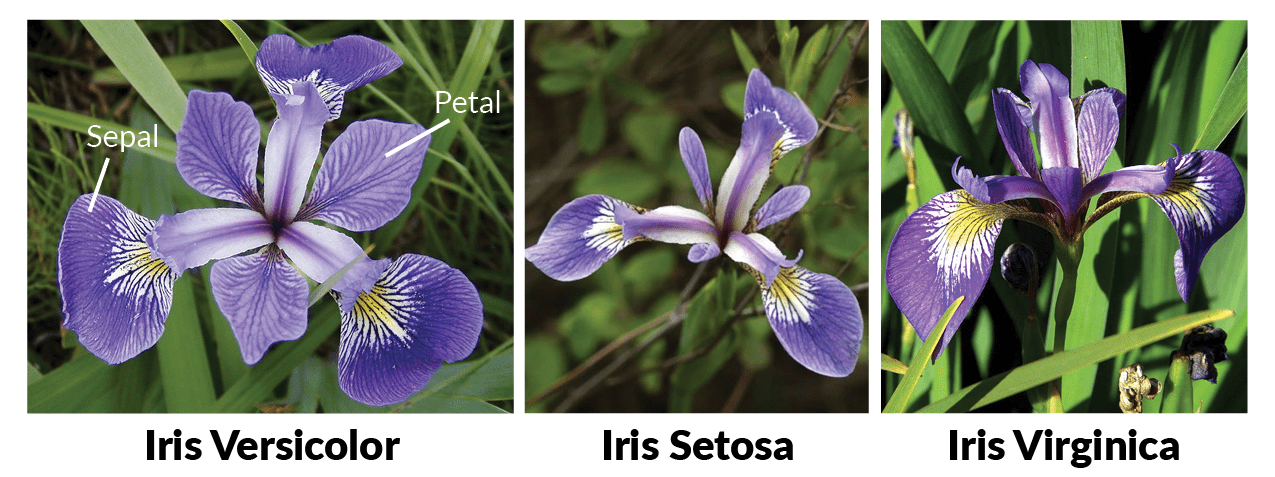

Начнём с задачи бинарной классификации: построим модель, которая **различает цветки Versicolor и Virginica**.

Уберём Setosa из данных и перекодируем целевую переменную так:
* Versicolor → 0
* Virginica → 1

In [3]:
df = data[data.target!=0]
df.target = df.target - 1
print(df.target.unique())
df.head()

[0 1]


,sepal length,sepal width,petal length,petal width,target
50,7.0,3.2,4.7,1.4,0
51,6.4,3.2,4.5,1.5,0
52,6.9,3.1,4.9,1.5,0
53,5.5,2.3,4.0,1.3,0
54,6.5,2.8,4.6,1.5,0


#### Статистика по данным:

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 50 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal length  100 non-null    float64
 1   sepal width   100 non-null    float64
 2   petal length  100 non-null    float64
 3   petal width   100 non-null    float64
 4   target        100 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 4.0 KB


In [5]:
df.describe()

,sepal length,sepal width,petal length,petal width,target
count,100.000000,100.000000,100.000000,100.000000,100.000000
mean,6.262000,2.872000,4.906000,1.676000,0.500000
std,0.662834,0.332751,0.825578,0.424769,0.502519
min,4.900000,2.000000,3.000000,1.000000,0.000000
25%,5.800000,2.700000,4.375000,1.300000,0.000000
50%,6.300000,2.900000,4.900000,1.600000,0.500000
75%,6.700000,3.025000,5.525000,2.000000,1.000000
max,7.900000,3.800000,6.900000,2.500000,1.000000


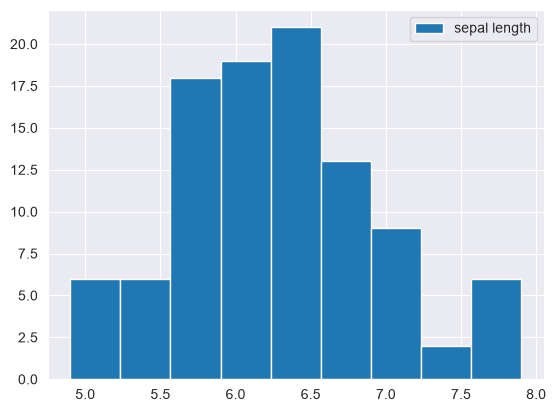

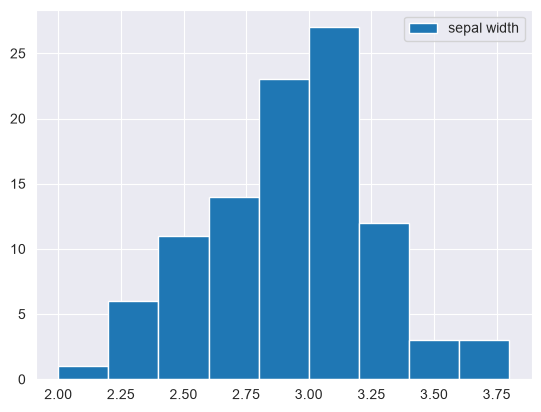

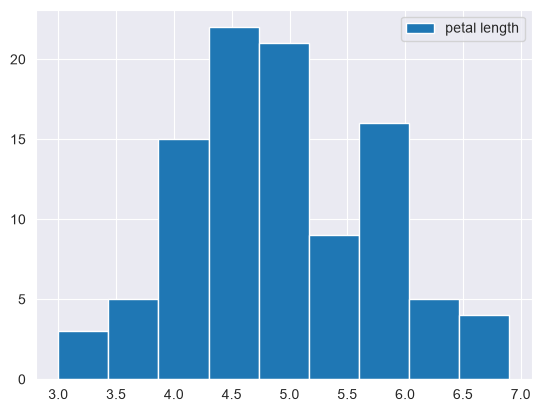

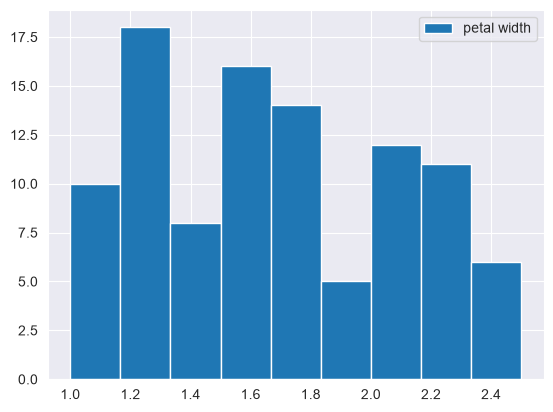

In [6]:
for name in names:
    df[name].hist(bins=9, label=name)
    plt.legend()
    plt.show()

#### Корреляции:

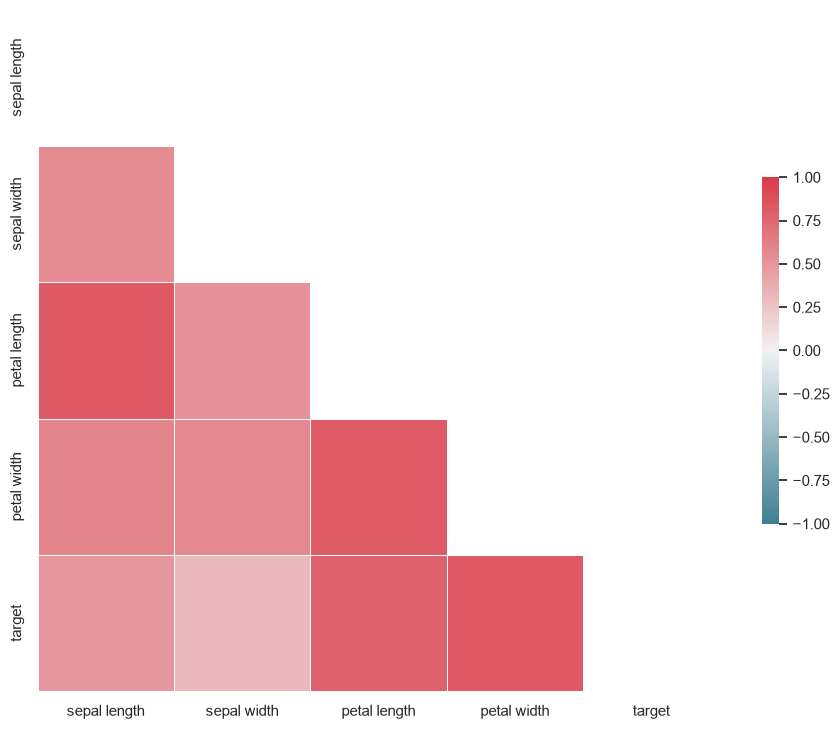

In [7]:
sns.set(style="white")

# Считаем матрицу корреляций
corr = df.corr()

# Делаем маску для верхнего треугольника
mask = np.zeros_like(corr, dtype=np.bool_)
mask[np.triu_indices_from(mask)] = True

# Создаём фигуру matplotlib
f, ax = plt.subplots(figsize=(11, 9))

# Создаём свою расходящуюся (diverging) палитру
cmap = sns.diverging_palette(220, 10, as_cmap=True)

# Рисуем тепловую карту (heatmap) с маской и правильным соотношением сторон

sns.heatmap(
    corr, mask=mask, cmap=cmap, center=0,
    square=True, vmin=-1, vmax=1, linewidths=.5,
    cbar_kws={"shrink": .5}
)

plt.show()

#### Ещё пара наглядных графиков:

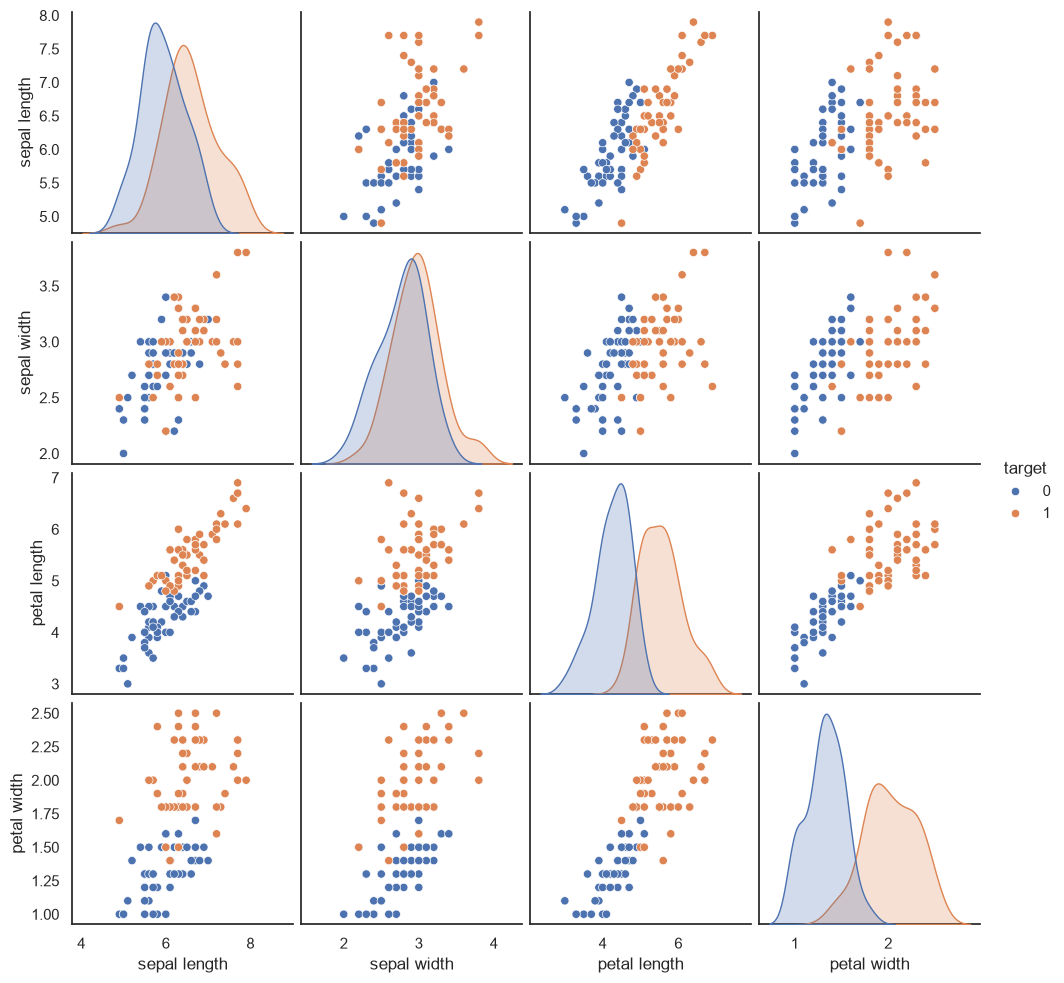

In [8]:
sns.pairplot(df, kind='scatter', hue='target')
plt.show()

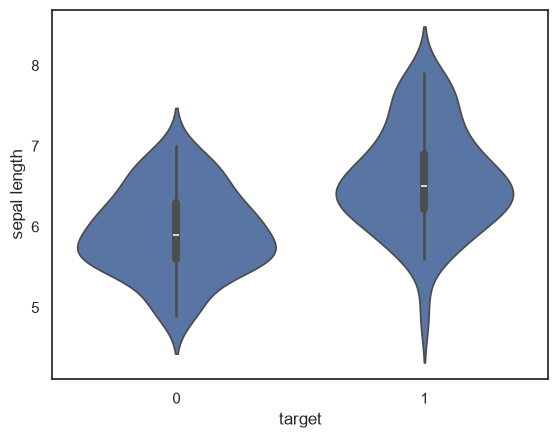

In [9]:
sns.violinplot(x=df["target"], y=df["sepal length"])
plt.show()

#### Проверяем ранг матрицы признаков:

In [10]:
np.linalg.matrix_rank(df.drop('target', axis=1))

np.int64(4)

#### Модель логистической регрессии

In [11]:
LogisticRegression?

In [12]:
model = LogisticRegression().fit(df.drop('target', axis=1), df['target'])
preds=model.predict(df.drop('target', axis=1))

accuracy_score(df['target'], preds)

0.96

In [13]:
pd.Series(data=model.coef_[0], index=model.feature_names_in_)

sepal length   -0.396293
sepal width    -0.512208
petal length    2.930197
petal width     2.413801
dtype: float64

#### Вопрос: чем отличаются L1- и L2-регуляризация?

**Логистическая регрессия с L1-регуляризацией**

In [14]:
model=LogisticRegression(penalty='l1', solver='liblinear').fit(df.drop('target', axis=1), df['target'])
preds=model.predict(df.drop('target', axis=1))

accuracy_score(df['target'], preds)

0.95

In [15]:
pd.Series(data=model.coef_[0], index=model.feature_names_in_)

sepal length   -2.625533
sepal width    -2.507056
petal length    3.264970
petal width     4.616141
dtype: float64

**Логистическая регрессия с L2-регуляризацией**

In [16]:
model=LogisticRegression(penalty='l2').fit(df.drop('target', axis=1), df['target'])
preds=model.predict(df.drop('target', axis=1))

accuracy_score(df['target'], preds)

0.96

In [17]:
pd.Series(data=model.coef_[0], index=model.feature_names_in_)

sepal length   -0.396293
sepal width    -0.512208
petal length    2.930197
petal width     2.413801
dtype: float64

In [18]:
solvers = ['newton-cg', 'sag', 'saga', 'lbfgs']
for solver in solvers:
    model = LogisticRegression(penalty='l2', solver=solver).fit(df.drop('target', axis=1), df['target'])
    preds = model.predict(df.drop('target', axis=1))

    print(solver, accuracy_score(df['target'], preds))

newton-cg 0.96
sag 0.97
saga 0.97
lbfgs 0.96


### Рисуем разделяющие границы (decision boundaries) для пар признаков

Берём три пары соседних признаков (из шести возможных). Для каждой пары обучаем логистическую регрессию только на этих двух признаках.

In [19]:
def plot_decision_boundaries(feature_1, feature_2):
    # строим сетку точек (meshgrid)
    xx, yy = np.mgrid[feature_1.min():feature_1.max():.01, feature_2.min():feature_2.max():.01]
    grid = np.c_[xx.ravel(), yy.ravel()]

    # создаём и обучаем модель
    model = LogisticRegression().fit(df[[feature_1.name, feature_2.name]], df['target'])
    probs = model.predict_proba(grid)[:, 1].reshape(xx.shape)

    # рисуем графики
    f, ax = plt.subplots(figsize=(15, 6))
    contour = ax.contourf(xx, yy, probs, 200, cmap="RdBu")
    ax_c = f.colorbar(contour)
    ax_c.set_label("$P(y = 1)$")

    ax.scatter(feature_1, feature_2, c=df['target'], s=50,
           cmap="RdBu", vmin=-.2, vmax=1.2,
           edgecolor="white", linewidth=1)

    ax.set(aspect="equal",
       xlim=(feature_1.min(), feature_1.max()), ylim=(feature_2.min(), feature_2.max()),
       xlabel=str(feature_1.name), ylabel=str(feature_2.name))

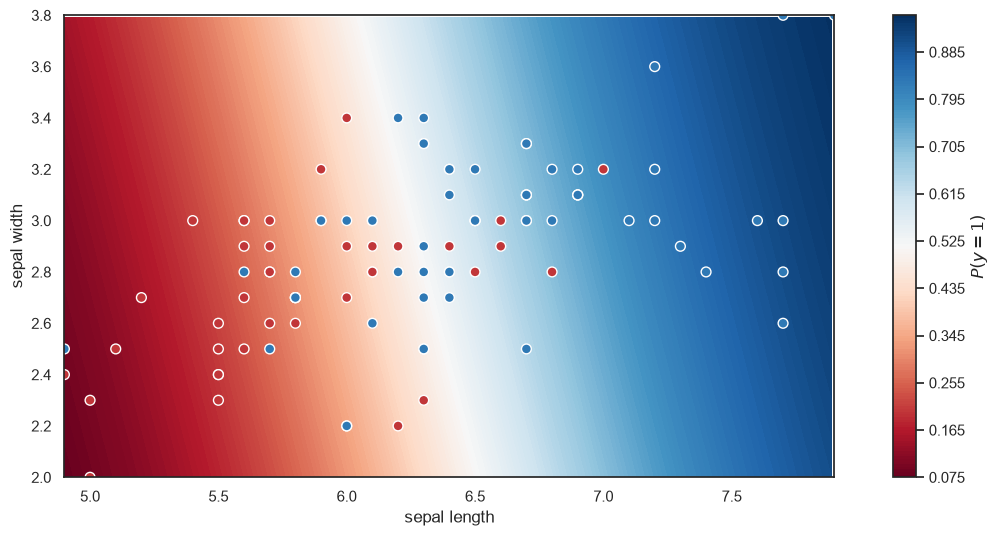

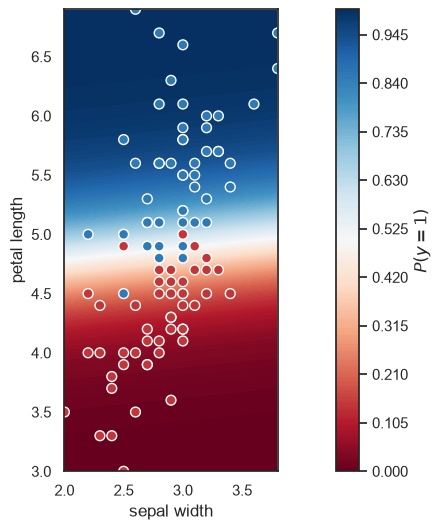

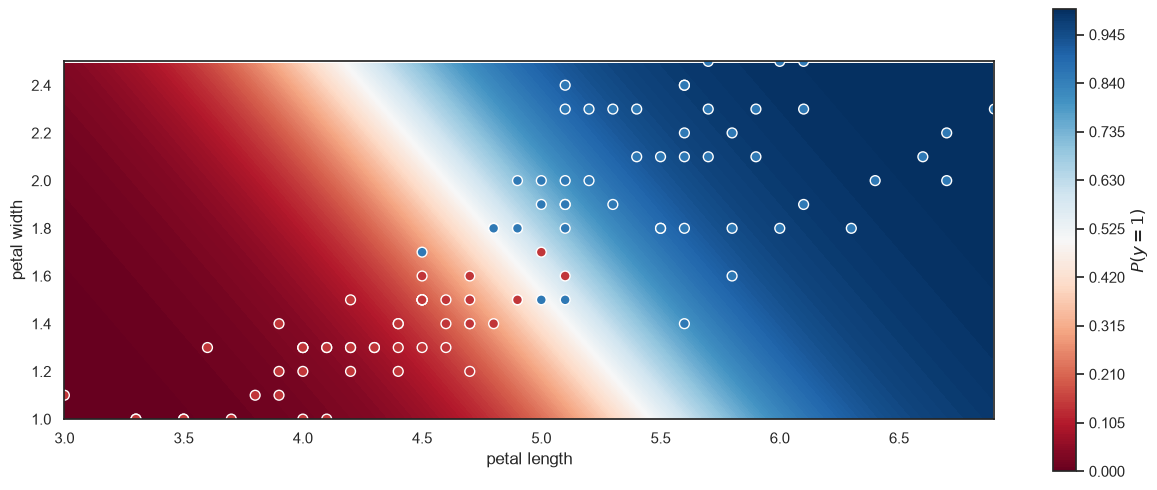

In [20]:
for i in range(df.shape[1]-2):
    plot_decision_boundaries(df.iloc[:, i], df.iloc[:, i+1])

### Разбираем результаты

Как видим, результаты почти одинаковые: accuracy у L2 (по умолчанию) — 0.96, у L1 — 0.95. 0.97 получилось только у солверов `sag` и `saga`, но они не успели сойтись за 100 итераций (предупреждение об этом скрыто фильтром `warnings`), поэтому на это число опираться не стоит. К тому же всё посчитано на тех же данных, на которых модель обучалась, а разница в 0.01 — это один объект из 100.

Но что на самом деле означает accuracy?

## Метрики классификации: матрица ошибок (confusion matrix)

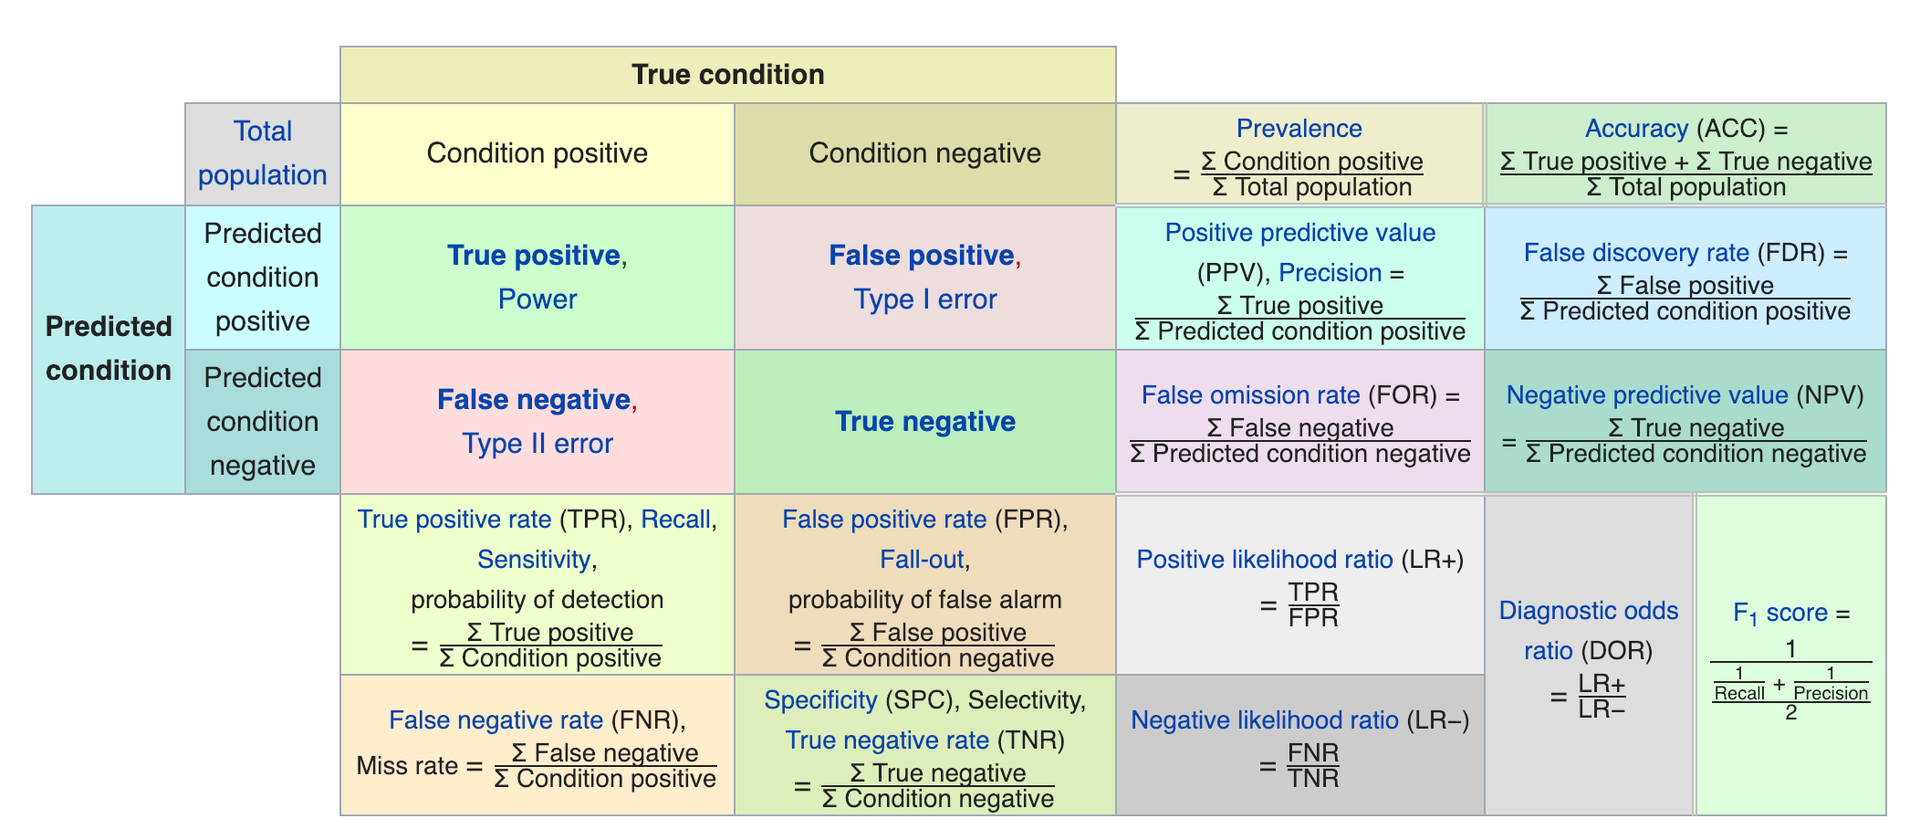

**Accuracy** (доля правильных ответов) — доля объектов, которые модель классифицировала правильно.

In [21]:
(preds == df['target']).sum() / df['target'].shape[0]

np.float64(0.96)

In [22]:
accuracy_score(df['target'], preds)

0.96

* **Prevalence** (распространённость) — доля объектов класса 1 среди всех объектов

In [23]:
prevalence = df.target.sum() / df.target.shape[0]
prevalence

np.float64(0.5)

* **True positives** (TP, истинно положительные) — число объектов класса 1, которые модель классифицировала правильно

In [24]:
tp = ((preds == 1) * (df.target == 1)).sum()
tp

np.int64(49)

* **True negatives** (TN, истинно отрицательные) — число объектов класса 0, которые модель классифицировала правильно

In [25]:
tn = ((preds == 0) * (df.target == 0)).sum()
tn

np.int64(47)

* **False positives** (FP, ложно положительные) — число объектов класса 0, которые модель классифицировала неправильно: отнесла к классу 1, хотя на самом деле они из класса 0

In [26]:
fp = ((preds == 1) * (df.target == 0)).sum()
fp

np.int64(3)

* **False negatives** (FN, ложно отрицательные) — число объектов класса 1, которые модель классифицировала неправильно: отнесла к классу 0, хотя на самом деле они из класса 1

In [27]:
fn = ((preds == 0) * (df.target == 1)).sum()
fn

np.int64(1)

* **Precision** (точность) — доля правильно классифицированных объектов класса 1 среди всех объектов, которые модель отнесла к классу 1

In [28]:
precision = tp / (preds==1).sum()
precision

np.float64(0.9423076923076923)

* **Recall** (полнота) — доля правильно классифицированных объектов класса 1 среди всех объектов класса 1

In [29]:
recall = tp / (df.target == 1).sum()
recall

np.float64(0.98)

* **F1 score** (F1-мера) — среднее гармоническое **Precision** и **Recall**

$$F_{1} score = 2\frac{Precision \cdot Recall}{Precision + Recall}$$

In [30]:
f1_score = 2 * precision * recall / (precision + recall)
f1_score

np.float64(0.9607843137254902)

In [31]:
sklearn.metrics.f1_score(df['target'], preds)

0.9607843137254902

* **$F_{\beta}$ score** — более общая F-мера с положительным вещественным параметром β. β выбирают так, чтобы recall был в β раз важнее, чем precision

$$F_{\beta} score = (1 + \beta^2)\frac{Precision \cdot Recall}{\beta^2 Precision + Recall}$$

In [32]:
betas = np.linspace(0, 10)

def f_beta_score(beta, precision, recall):
    fb = (1 + beta**2) * precision * recall / (beta * beta * precision + recall)
    return fb

for beta in betas:
    print(f'beta: {np.round(beta, 2)}, f_beta_score: {np.round(f_beta_score(beta, precision, recall), 3)}')


beta: 0.0, f_beta_score: 0.942
beta: 0.2, f_beta_score: 0.944
beta: 0.41, f_beta_score: 0.948
beta: 0.61, f_beta_score: 0.952
beta: 0.82, f_beta_score: 0.957
beta: 1.02, f_beta_score: 0.961
beta: 1.22, f_beta_score: 0.965
beta: 1.43, f_beta_score: 0.967
beta: 1.63, f_beta_score: 0.969
beta: 1.84, f_beta_score: 0.971
beta: 2.04, f_beta_score: 0.972
beta: 2.24, f_beta_score: 0.974
beta: 2.45, f_beta_score: 0.974
beta: 2.65, f_beta_score: 0.975
beta: 2.86, f_beta_score: 0.976
beta: 3.06, f_beta_score: 0.976
beta: 3.27, f_beta_score: 0.977
beta: 3.47, f_beta_score: 0.977
beta: 3.67, f_beta_score: 0.977
beta: 3.88, f_beta_score: 0.978
beta: 4.08, f_beta_score: 0.978
beta: 4.29, f_beta_score: 0.978
beta: 4.49, f_beta_score: 0.978
beta: 4.69, f_beta_score: 0.978
beta: 4.9, f_beta_score: 0.978
beta: 5.1, f_beta_score: 0.979
beta: 5.31, f_beta_score: 0.979
beta: 5.51, f_beta_score: 0.979
beta: 5.71, f_beta_score: 0.979
beta: 5.92, f_beta_score: 0.979
beta: 6.12, f_beta_score: 0.979
beta: 6.33, 

In [33]:
sklearn.metrics.fbeta_score(df['target'], preds, beta=2)

0.9722222222222222

##### Другие пороговые метрики

* **Condition Positive** — число объектов, которые на самом деле относятся к классу 1

In [34]:
condition_positive = (df.target == 1).sum()
condition_positive

np.int64(50)

* **Condition Negative** — число объектов, которые на самом деле относятся к классу 0

In [35]:
condition_negative = (df.target == 0).sum()
condition_negative

np.int64(50)

* **Predicted Condition Positive** — число объектов, которые модель отнесла к классу 1

In [36]:
predicted_cp = (preds==1).sum()
predicted_cp

np.int64(52)

* **Predicted Condition Negative** — число объектов, которые модель отнесла к классу 0

In [37]:
predicted_cn = (preds==0).sum()
predicted_cn

np.int64(48)

* **TPR**, оно же **True Positive Rate**, оно же **Recall**, оно же **Sensitivity** (чувствительность), оно же **Probability of detection** — доля правильно классифицированных объектов класса 1 среди всех объектов класса 1

In [38]:
tpr = tp / condition_positive
tpr

np.float64(0.98)

* **TNR**, оно же **True Negative Rate**, оно же **Specificity** (специфичность), оно же **Selectivity** — доля правильно классифицированных объектов класса 0 среди всех объектов класса 0

In [39]:
tnr = tn / condition_negative
tnr

np.float64(0.94)

* **FNR**, оно же **False Negative Rate**, оно же **Miss rate** (доля пропусков) — доля неправильно классифицированных объектов класса 1 среди всех объектов класса 1

In [40]:
fnr = fn / condition_positive
fnr

np.float64(0.02)

* **FPR**, оно же **False Positive Rate**, оно же **Fall-out**, оно же **Probability of false alarm** (вероятность ложной тревоги) — доля неправильно классифицированных объектов класса 0 среди всех объектов класса 0

In [41]:
fpr = fp / condition_negative
fpr

np.float64(0.06)

* **NPV**, оно же **Negative Predictive Value** — доля правильно классифицированных объектов класса 0 среди всех объектов, которые модель отнесла к классу 0

In [42]:
npv = tn / predicted_cn
npv

np.float64(0.9791666666666666)

* **False Omission Rate**, оно же **FOR** — доля неправильно классифицированных объектов класса 1 среди всех объектов, которые модель отнесла к классу 0

In [43]:
fo_rate = fn / predicted_cn
fo_rate

np.float64(0.020833333333333332)

* **False Discovery Rate**, оно же **FDR** — доля неправильно классифицированных объектов класса 0 среди всех объектов, которые модель отнесла к классу 1

In [44]:
fd_rate = fp / predicted_cp
fd_rate

np.float64(0.057692307692307696)

* **Positive Likelihood Ratio** (положительное отношение правдоподобия)

$$LR+ = \frac{TPR}{FPR}$$

In [45]:
lr_positive = tpr / fpr
lr_positive

np.float64(16.333333333333332)

* **Negative Likelihood Ratio** (отрицательное отношение правдоподобия)

$$LR- = \frac{FNR}{TNR}$$

In [46]:
lr_negative = fnr / tnr
lr_negative

np.float64(0.021276595744680854)

* **Diagnostic Odds Ratio** (диагностическое отношение шансов)

$$DOR = \frac{LR+}{LR-}$$

In [47]:
dor = lr_positive / lr_negative
dor

np.float64(767.6666666666665)

### ROC-кривая

**Обозначения:**
- $\mu$ — порог: модель относит объект к положительному классу $\omega_{1}$ (у нас это класс 1), если $\widehat{p}(+|x) > \mu$
- $\varepsilon_{1}$ — доля ошибок на объектах класса 1, то есть FNR
- $\varepsilon_{2}$ — доля ошибок на объектах класса 0, то есть FPR

* ROC-кривая (ROC curve) — это функция TPR(FPR). Она показывает, как вероятность правильной классификации объектов положительного класса («recognition rate», доля распознанных) меняется в зависимости от вероятности ошибки на объектах отрицательного класса («false alarm», ложная тревога).
* Строится как набор точек TPR($\mu$), FPR($\mu$).
* Если $\mu \downarrow$, алгоритм чаще предсказывает $\omega_{1}$, и
    * TPR=$1-\varepsilon_{1}$ $\uparrow$
    * FPR=$\varepsilon_{2}$ $\uparrow$

* Характеризует качество классификации при разных $\mu$.
    * чем сильнее ROC-кривая выгнута вверх (concave), тем лучше

* $TPR = \frac{TP}{TP + FN}=\frac{TP}{Pos}$
* $FPR = \frac{FP}{FP + TN} = \frac{FP}{Neg}$

<style type="text/css">
.tg  {border-collapse:collapse;border-spacing:0;}
.tg td{font-family:Arial, sans-serif;font-size:14px;padding:10px 5px;border-style:solid;border-width:1px;overflow:hidden;word-break:normal;}
.tg th{font-family:Arial, sans-serif;font-size:14px;font-weight:normal;padding:10px 5px;border-style:solid;border-width:1px;overflow:hidden;word-break:normal;}
</style>


### ROC-AUC
* Площадь под ROC-кривой (area under the ROC curve)

* Общая характеристика качества сразу для всех $\mu$
* AUC $\in[0,1]$
    * AUC = 0.5 — то же самое, что случайное угадывание
    * AUC = 1 — классификация без ошибок.

* Свойство AUC: он равен вероятности того, что для 2 случайных объектов $x_{1}\in \text{"+"}$ и $x_{2}\in \text{"-"}$ выполнится $\widehat{p}(+|x_{1})>\widehat{p}(+|x_2)$

* А что будет, если классы несбалансированы?

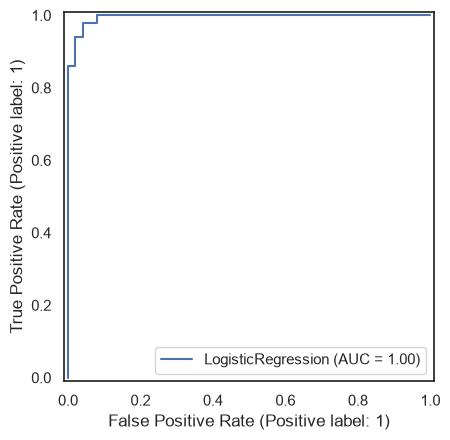

In [48]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(model, df.drop('target', axis=1), df['target'])

In [49]:
preds_proba = model.predict_proba(df.drop('target', axis=1))

sklearn.metrics.roc_auc_score(df['target'], preds_proba[:, 1])

0.9952000000000001

Значение метрики не меняется при монотонно возрастающих преобразованиях

In [50]:
sklearn.metrics.roc_auc_score(df['target'], 10*preds_proba[:, 1])

0.9952000000000001

При монотонно убывающих преобразованиях значение метрики становится равным 1 − AUC

In [51]:
sklearn.metrics.roc_auc_score(df['target'], -10*preds_proba[:, 1])

0.004800000000000002

А что, если в целевой переменной всего одно значение?

## Работа с несбалансированными данными

Датасет называют **несбалансированным** (imbalanced), если число объектов в разных классах сильно, а иногда и экстремально, различается.

В такой ситуации accuracy плохо отражает качество модели.

Что можно сделать?

* Сбалансировать датасет
* Взять метрики, которые замечают дисбаланс: PR-AUC, $F_\beta$ score, Precision, Recall
* Задать классам веса, обратно пропорциональные их размеру: чем реже класс, тем больше вес (так можно сделать в некоторых моделях sklearn — параметр `class_weight='balanced'`, в библиотеках градиентного бустинга и нейросетей)

**Почему PR-AUC, а не ROC-AUC.** PR-кривая — это precision в зависимости от recall при разных порогах, PR-AUC — площадь под ней (в sklearn — `average_precision_score`). ROC-AUC и Specificity дисбаланса не замечают: TPR, FPR и TNR считаются внутри своего класса. Поэтому ROC-AUC может быть высоким, даже когда большинство срабатываний модели ложные. Precision считается по обоим классам сразу, и PR-AUC это видит.

Важно: у случайной модели PR-AUC равен доле положительного класса, а не 0.5. Например, при 1% положительных PR-AUC = 0.3 — это в 30 раз лучше случайной модели.

Сегодня научимся искусственно балансировать датасет. Для этого есть несколько приёмов:

* Undersampling: уменьшаем число объектов большого класса (или классов)
* Oversampling: увеличиваем число объектов малого класса
* Комбинируем oversampling и undersampling
* Создаём сбалансированные подвыборки для ансамбля

<a href="https://pypi.org/project/imbalanced-learn/">ImbLearn</a> — библиотека для ресемплинга (resampling), в ней много разновидностей SMOTE

In [ ]:
%pip install imbalanced-learn

In [53]:
import imblearn

### Undersampling с помощью NearMiss

In [54]:
# Авторы: Guillaume Lemaitre <g.lemaitre58@gmail.com>
# Лицензия: MIT

from collections import Counter

from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from imblearn.datasets import make_imbalance
from imblearn.under_sampling import NearMiss
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import make_pipeline
from imblearn.metrics import classification_report_imbalanced

print(__doc__)

RANDOM_STATE = 42

# Создаём папку для загрузки датасета
iris = load_iris()
X, y = make_imbalance(
    iris.data,
    iris.target,
    sampling_strategy={0: 25, 1: 50, 2: 50},
    random_state=RANDOM_STATE,
)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=RANDOM_STATE)

print(f"Training target statistics: {Counter(y_train)}")
print(f"Testing target statistics: {Counter(y_test)}")

# Собираем пайплайн
pipeline = make_pipeline(
    NearMiss(version=2), StandardScaler(), LogisticRegression(random_state=RANDOM_STATE)
)
pipeline.fit(X_train, y_train)

# Классифицируем и выводим отчёт с результатами
print(classification_report_imbalanced(y_test, pipeline.predict(X_test)))

Automatically created module for IPython interactive environment
Training target statistics: Counter({np.int64(1): 38, np.int64(2): 38, np.int64(0): 17})
Testing target statistics: Counter({np.int64(1): 12, np.int64(2): 12, np.int64(0): 8})
                   pre       rec       spe        f1       geo       iba       sup

          0       1.00      1.00      1.00      1.00      1.00      1.00         8
          1       0.88      0.58      0.95      0.70      0.74      0.53        12
          2       0.69      0.92      0.75      0.79      0.83      0.70        12

avg / total       0.84      0.81      0.89      0.81      0.84      0.71        32



### Oversampling с помощью RandomOverSampler

In [55]:
print(f"Training target statistics: {Counter(y_train)}")
print(f"Testing target statistics: {Counter(y_test)}")

# Собираем пайплайн
pipeline = make_pipeline(
    RandomOverSampler(), StandardScaler(), LogisticRegression(random_state=RANDOM_STATE)
)
pipeline.fit(X_train, y_train)

# Классифицируем и выводим отчёт с результатами
print(classification_report_imbalanced(y_test, pipeline.predict(X_test)))

Training target statistics: Counter({np.int64(1): 38, np.int64(2): 38, np.int64(0): 17})
Testing target statistics: Counter({np.int64(1): 12, np.int64(2): 12, np.int64(0): 8})
                   pre       rec       spe        f1       geo       iba       sup

          0       1.00      1.00      1.00      1.00      1.00      1.00         8
          1       0.92      0.92      0.95      0.92      0.93      0.87        12
          2       0.92      0.92      0.95      0.92      0.93      0.87        12

avg / total       0.94      0.94      0.96      0.94      0.95      0.90        32

